In [1]:
from keras.models import Sequential
from keras.utils import get_file, to_categorical
from keras.layers import Embedding, Flatten, Dense, SpatialDropout1D, BatchNormalization, Dropout, SimpleRNN
from keras.layers import GRU, LSTM, Bidirectional, Conv1D, MaxPooling1D, GlobalMaxPooling1D

from tensorflow.keras.preprocessing.text import Tokenizer

import os   # Модуль для работы с файловой системой

import glob # Вспомогательный модуль для работы с файловой системой
import numpy as np

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # Для работы с матрицей ошибок

import matplotlib.pyplot as plt
%matplotlib inline


In [22]:
!pip install navec

In [23]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar

--2025-09-13 12:52:39--  https://storage.yandexcloud.net/natasha-navec/packs/navec_hudlit_v1_12B_500K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 53012480 (51M) [application/x-tar]
Saving to: ‘navec_hudlit_v1_12B_500K_300d_100q.tar’

navec_hudlit_v1_12B 100%[===================>]  50.56M  15.9MB/s    in 4.1s    

2025-09-13 12:52:45 (12.5 MB/s) - ‘navec_hudlit_v1_12B_500K_300d_100q.tar’ saved [53012480/53012480]



In [24]:
from navec import Navec
navec = Navec.load('navec_hudlit_v1_12B_500K_300d_100q.tar')

In [2]:
data_path = get_file(
    "russian_literature.zip",
    "https://storage.yandexcloud.net/academy.ai/russian_literature.zip"
)

!unzip -qo "{data_path}" -d ./dataset

21547079/21547079 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
error:  cannot create ./dataset/poems/Blok/╨б╤В╨╕╤Е╨╛╤В╨▓╨╛╤А╨╡╨╜╨╕╤П 1897-1903 ╨│╨│, ╨╜╨╡ ╨▓╨╛╤И╨╡╨┤╤И╨╕╨╡ ╨▓ ╨╛╤Б╨╜╨╛╨▓╨╜╨╛╨╡ ╤Б╨╛╨▒╤А╨░╨╜╨╕╨╡.txt
        File name too long
error:  cannot create ./dataset/prose/Gogol/╨Я╨╛╨▓╨╡╤Б╤В╤М ╨╛ ╤В╨╛╨╝, ╨║╨░╨║ ╨┐╨╛╤Б╤Б╨╛╤А╨╕╨╗╤Б╤П ╨Ш╨▓╨░╨╜ ╨Ш╨▓╨░╨╜╨╛╨▓╨╕╤З ╤Б ╨Ш╨▓╨░╨╜╨╛╨╝ ╨Э╨╕╨║╨╕╤Д╨╛╤А╨╛╨▓╨╕╤З╨╡╨╝.txt
        File name too long
error:  cannot create ./dataset/publicism/Tolstoy/╨Ф╨╛╨║╨╗╨░╨┤, ╨┐╤А╨╕╨│╨╛╤В╨╛╨▓╨╗╨╡╨╜╨╜╤Л╨╣ ╨┤╨╗╤П ╨║╨╛╨╜╨│╤А╨╡╤Б╤Б╨░ ╨╛ ╨╝╨╕╤А╨╡ ╨▓ ╨б╤В╨╛╨║╨│╨╛╨╗╤М╨╝╨╡.txt
        File name too long
error:  cannot create ./dataset/publicism/Tolstoy/╨Я╨╛╤З╨╡╨╝╤Г ╤Е╤А╨╕╤Б╤В╨╕╨░╨╜╤Б╨║╨╕╨╡ ╨╜╨░╤А╨╛╨┤╤Л ╨▓╨╛╨╛╨▒╤Й╨╡ ╨╕ ╨▓ ╨╛╤Б╨╛╨▒╨╡╨╜╨╜╨╛╤Б╤В╨╕ ╤А╤Г╤Б╤Б╨║╨╕╨╣ ╨╜╨░╤Е╨╛╨┤╤П╤В╤Б╤П ╤В╨╡╨┐╨╡╤А╤М ╨▓ ╨▒╨╡╨┤╤Б╤В╨▓╨╡╨╜╨╜╨╛╨╝ ╨┐╨╛╨╗╨╛╨╢╨╡╨╜╨╕╨╕.txt
        File name too long


In [3]:
FILE_DIR_POEMS = './dataset/poems'
file_list_poems = os.listdir(FILE_DIR_POEMS)
print("Поэты:")
print(file_list_poems)

Поэты:
['Blok', 'Lermontov', 'Nekrasov', 'Pushkin']


In [4]:
FILE_DIR_PROSE = './dataset/prose'
file_list_prose = os.listdir(FILE_DIR_PROSE)
print("Прозаики:")
print(file_list_prose)

Прозаики:
['Blok', 'Lermontov', 'Dostoevsky', 'Bryusov', 'Gogol', 'Gorky', 'Turgenev', 'Chekhov', 'Pushkin', 'Herzen', 'Tolstoy']


In [5]:
CLASS_LIST = list(set(file_list_poems + file_list_prose))
print("Общий список писателей:")
print(CLASS_LIST)

Общий список писателей:
['Chekhov', 'Dostoevsky', 'Herzen', 'Gogol', 'Turgenev', 'Lermontov', 'Blok', 'Nekrasov', 'Bryusov', 'Gorky', 'Tolstoy', 'Pushkin']


In [38]:
CLASS_LIST = ['Turgenev', 'Tolstoy', 'Pushkin', 'Chekhov']
print("Выбранный список писателей:")
print(CLASS_LIST)

Выбранный список писателей:
['Turgenev', 'Tolstoy', 'Pushkin', 'Chekhov']


In [39]:
all_texts = {} # Собираем в словарь весь датасет

for author in CLASS_LIST:
    all_texts[author] = '' # Инициализируем пустой строкой новый ключ словаря
    for path in glob.glob('./dataset/prose/{}/*.txt'.format(author)) +  glob.glob('./dataset/poems/{}/*.txt'.format(author)): # Поиск файлов по шаблону
        with open(f'{path}', 'r', errors='ignore') as f: # игнорируем ошибки (например символы из другой кодировки)
            # Загрузка содержимого файла в строку
            text = f.read()

        all_texts[author]  += ' ' + text.replace('\n', ' ') # Заменяем символ перехода на новую строку пробелом

In [40]:
embedding_dim = 300    # размерность векторов эмбединга (300d в имени эмбединга)
max_words = 15000      # Количество слов, рассматриваемых как признаки

# Используется встроенный в Keras токенизатор для разбиения текста и построения частотного словаря
tokenizer = Tokenizer(num_words=max_words,
                      filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                      lower=True, split=' ', char_level=False)


# Построение частотного словаря по текстам
tokenizer.fit_on_texts(all_texts.values())

In [41]:
seq_train = tokenizer.texts_to_sequences(all_texts.values())

In [51]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train)
print(f'Датасет состоит из {total} слов')

print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    print(f'{author} - {len(seq_train[cls])} слов, доля в общей базе: {len(seq_train[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))


median = int(np.median(mean_list)) # Зафиксировали медианное значение
CLASS_LIST_BALANCE = [] # Сбалансированный набор меток
seq_train_balance = []
for author in CLASS_LIST:
    cls = CLASS_LIST.index(author)
    if len(seq_train[cls]) > median * 0.6:
      seq_train_balance.append(seq_train[cls][:median])
      CLASS_LIST_BALANCE.append(author)

Датасет состоит из 1981325 слов
Общая выборка по писателям (по словам):
Turgenev - 307677 слов, доля в общей базе: 15.53%
Tolstoy - 1257947 слов, доля в общей базе: 63.49%
Pushkin - 170149 слов, доля в общей базе: 8.59%
Chekhov - 245552 слов, доля в общей базе: 12.39%
Среднее значение слов:  495331.0
Медианное значение слов:  276614.5


In [52]:
total = sum(len(i) for i in seq_train_balance)

print('Сбалансированная выборка по писателям (по словам):')
mean_list_balance = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list_balance = np.append(mean_list_balance, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list_balance.mean()))
print('Медианное значение слов: ', np.median(mean_list_balance))

Сбалансированная выборка по писателям (по словам):
Turgenev - 276614 слов, доля в общей базе: 28.55%
Tolstoy - 276614 слов, доля в общей базе: 28.55%
Pushkin - 170149 слов, доля в общей базе: 17.56%
Chekhov - 245552 слов, доля в общей базе: 25.34%
Среднее значение слов:  242232.0
Медианное значение слов:  261083.0


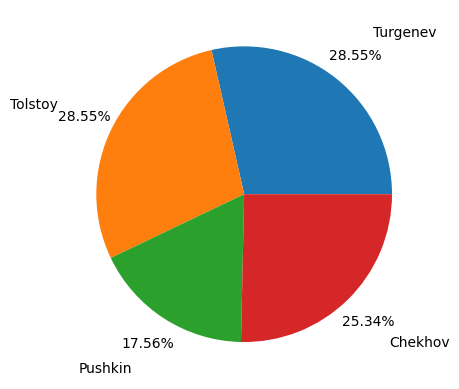

In [53]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance],  # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,            # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

In [54]:
# используем генератор цикла для получения длины текстов по каждому автору
total = sum(len(i) for i in seq_train_balance)
print(f'Датасет состоит из {total} слов')

Датасет состоит из 968929 слов


In [55]:
print('Общая выборка по писателям (по словам):')
mean_list = np.array([])
for author in CLASS_LIST_BALANCE:
    cls = CLASS_LIST_BALANCE.index(author)
    print(f'{author} - {len(seq_train_balance[cls])} слов, доля в общей базе: {len(seq_train_balance[cls])/total*100 :.2f}%')
    mean_list = np.append(mean_list, len(seq_train_balance[cls]))

print('Среднее значение слов: ', np.round(mean_list.mean()))
print('Медианное значение слов: ', np.median(mean_list))

Общая выборка по писателям (по словам):
Turgenev - 276614 слов, доля в общей базе: 28.55%
Tolstoy - 276614 слов, доля в общей базе: 28.55%
Pushkin - 170149 слов, доля в общей базе: 17.56%
Chekhov - 245552 слов, доля в общей базе: 25.34%
Среднее значение слов:  242232.0
Медианное значение слов:  261083.0


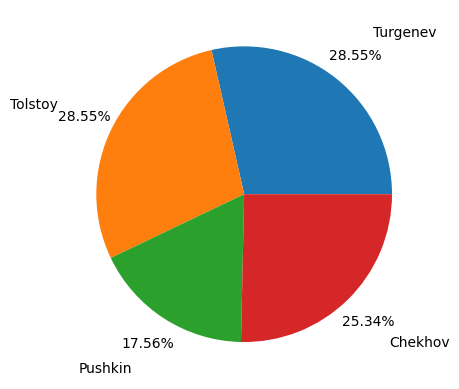

In [56]:
fig, ax = plt.subplots()
ax.pie([len(i) for i in seq_train_balance], # формируем список значений как длина символов текста каждого автора
       labels=CLASS_LIST_BALANCE,                    # список меток
       pctdistance=1.2,                      # дистанция размещения % (1 - граница окружности)
       labeldistance=1.4,                    # размещение меток (1 - граница окружности)
       autopct='%1.2f%%'                     # формат для % (2 знака после запятой)
      )
plt.show()

In [57]:
import numpy as np
from keras.utils import to_categorical

WIN_SIZE = 1000   # Ширина окна в токенах
WIN_STEP = 100    # Шаг окна в токенах

# Функция разбиения последовательности на отрезки скользящим окном
def seq_split(sequence, win_size, step):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, step)]

def seq_vectorize(
    seq_list,   # Последовательность
    test_split, # Доля на тестовую выборку (10%)
    class_list, # Список классов
    win_size,   # Ширина скользящего окна
    step        # Шаг скользящего окна
):

    # Списки для результирующих данных
    x_train, y_train, x_val, y_val, x_test, y_test =  [], [], [], [], [], []

    for class_item in class_list:
        # Получаем индекс класса
        cls = class_list.index(class_item)

        # Общее количество элементов в классе
        total_samples = len(seq_list[cls])

        # Пороги для разбивки
        train_val_split = int(total_samples * 0.8)  # 80% для обучающей и проверочной
        val_test_split = int(total_samples * 0.9)   # 10% для проверочной и 10% для тестовой

        # Разбиваем последовательность токенов класса на отрезки
        vectors_train = seq_split(seq_list[cls][:train_val_split], win_size, step)  # Обучающая выборка
        vectors_val = seq_split(seq_list[cls][train_val_split:val_test_split], win_size, step)  # Проверочная выборка
        vectors_test = seq_split(seq_list[cls][val_test_split:], win_size, step)  # Тестовая выборка

        # Добавляем отрезки в выборку
        x_train += vectors_train
        x_val += vectors_val
        x_test += vectors_test

        # Генерируем метки
        y_train += [to_categorical(cls, len(class_list))] * len(vectors_train)
        y_val += [to_categorical(cls, len(class_list))] * len(vectors_val)
        y_test += [to_categorical(cls, len(class_list))] * len(vectors_test)

    # Возвращаем результаты как numpy-массивы
    return np.array(x_train), np.array(y_train), np.array(x_val), np.array(y_val), np.array(x_test), np.array(y_test)

In [58]:
x_train, y_train, x_val, y_val, x_test, y_test = seq_vectorize(seq_train_balance, 0.1, CLASS_LIST_BALANCE, WIN_SIZE, WIN_STEP)

In [59]:
print(f'Форма входных данных для обучающей выборки: {x_train.shape}')
print(f'Форма выходных данных (меток) для обучающей выборки: {y_train.shape}')

Форма входных данных для обучающей выборки: (7713, 1000)
Форма выходных данных (меток) для обучающей выборки: (7713, 4)


In [60]:
print(f'Форма входных данных для тестовой выборки: {x_val.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_val.shape}')

Форма входных данных для тестовой выборки: (931, 1000)
Форма выходных данных (меток) для тестовой выборки: (931, 4)


In [61]:
print(f'Форма входных данных для тестовой выборки: {x_test.shape}')
print(f'Форма выходных данных (меток) для тестовой выборки: {y_test.shape}')

Форма входных данных для тестовой выборки: (931, 1000)
Форма выходных данных (меток) для тестовой выборки: (931, 4)


In [62]:
# Вывод графиков точности и ошибки
def show_plot(history, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5))
    fig.suptitle('График процесса обучения модели: '+title)
    ax1.plot(history.history['accuracy'],
               label='График точности на обучающей выборке')
    ax1.plot(history.history['val_accuracy'],
               label='График точности на проверочной выборке')
    ax1.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('График точности')
    ax1.legend()

    ax2.plot(history.history['loss'],
               label='Ошибка на обучающей выборке')
    ax2.plot(history.history['val_loss'],
               label='Ошибка на проверочной выборке')
    ax2.xaxis.get_major_locator().set_params(integer=True) # На оси х показываем целые числа
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()

# Функция вывода предсказанных значений
def show_confusion_matrix(y_true, y_pred, class_labels):
    # Матрица ошибок
    cm = confusion_matrix(np.argmax(y_true, axis=1),
                          np.argmax(y_pred, axis=1),
                          normalize='true')
    # Округление значений матрицы ошибок
    cm = np.around(cm, 3)

    # Отрисовка матрицы ошибок
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title(f'Матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()  # Убираем ненужную цветовую шкалу
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)          # Наклон меток горизонтальной оси
    plt.show()


    # Средняя точность распознавания определяется как среднее диагональных элементов матрицы ошибок
    print('\nСредняя точность распознавания: {:3.0f}%'.format(100. * cm.diagonal().mean()))

In [63]:
def loadEmbedding():
    word_index = tokenizer.word_index
    embeddings_index = navec

    embedding_matrix = np.zeros((max_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_words:
            embedding_vector = embeddings_index.get(word)
            if embedding_vector is not None:
                embedding_matrix[i] = embedding_vector

    return embedding_matrix

In [68]:
from keras.regularizers import l2
model_MIX = Sequential()


embedding_layer = Embedding(max_words, embedding_dim, input_length=WIN_SIZE, weights=loadEmbedding())
model_MIX.add(embedding_layer)
model_MIX.add(SpatialDropout1D(0.3))
model_MIX.add(BatchNormalization())

embedding_layer.trainable = False

# Два двунаправленных рекуррентных слоя LSTM
model_MIX.add(Bidirectional(LSTM(32, return_sequences=True)))
model_MIX.add(Bidirectional(LSTM(32, return_sequences=True)))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Два рекуррентных слоя GRU
model_MIX.add(GRU(64, return_sequences=True, reset_after=True))
model_MIX.add(GRU(64, reset_after=True))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())

# Дополнительный полносвязный слой
model_MIX.add(Dense(100, activation='relu', kernel_regularizer=l2(0.01)))
model_MIX.add(Dropout(0.3))
model_MIX.add(BatchNormalization())
model_MIX.add(Dense(len(CLASS_LIST_BALANCE), activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [69]:
from keras.callbacks import ModelCheckpoint, EarlyStopping
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, mode='max', verbose=2)
early_stopping = EarlyStopping(monitor='val_accuracy', patience=10, verbose=1, restore_best_weights=True)

In [27]:
model_MIX.layers[0].trainable = False

In [70]:
model_MIX.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_mix = model_MIX.fit(x_train, y_train, epochs=50, batch_size=128, validation_data=(x_val, y_val),  callbacks=[checkpoint, early_stopping])

Epoch 1/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.2695 - loss: 2.5490
Epoch 1: val_accuracy improved from -inf to 0.28571, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 23s 266ms/step - accuracy: 0.2697 - loss: 2.5466 - val_accuracy: 0.2857 - val_loss: 2.0143
Epoch 2/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3175 - loss: 2.1186
Epoch 2: val_accuracy improved from 0.28571 to 0.31472, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - accuracy: 0.3179 - loss: 2.1173 - val_accuracy: 0.3147 - val_loss: 1.8449
Epoch 3/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.3982 - loss: 1.8236
Epoch 3: val_accuracy improved from 0.31472 to 0.43609, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 256ms/step - accuracy: 0.3984 - loss: 1.8227 - val_accuracy: 0.4361 - val_loss: 1.5833
Epoch 4/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.4835 - loss: 1.5591
Epoch 4: val_accuracy improved from 0.43609 to 0.67132, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 254ms/step - accuracy: 0.4840 - loss: 1.5579 - val_accuracy: 0.6713 - val_loss: 1.1513
Epoch 5/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5624 - loss: 1.3422
Epoch 5: val_accuracy did not improve from 0.67132
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.5623 - loss: 1.3422 - val_accuracy: 0.5918 - val_loss: 1.4830
Epoch 6/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.5583 - loss: 1.2690
Epoch 6: val_accuracy did not improve from 0.67132
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 246ms/step - accuracy: 0.5578 - loss: 1.2696 - val_accuracy: 0.4286 - val_loss: 1.5343
Epoch 7/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.5649 - loss: 1.2001
Epoch 7: val_accuracy did not improve from 0.67132
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.5654 - loss: 1.1990 - val_accuracy: 0.5134 - val_loss: 1.2351
Epoch 8/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.6754 - loss: 0.9492
Epoch 8: val_accuracy improved 

...

61/61 ━━━━━━━━━━━━━━━━━━━━ 16s 255ms/step - accuracy: 0.9561 - loss: 0.1744 - val_accuracy: 0.9624 - val_loss: 0.1318
Epoch 14/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9743 - loss: 0.1182
Epoch 14: val_accuracy did not improve from 0.96241
61/61 ━━━━━━━━━━━━━━━━━━━━ 15s 252ms/step - accuracy: 0.9743 - loss: 0.1180 - val_accuracy: 0.9517 - val_loss: 0.1825
Epoch 15/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9696 - loss: 0.1171
Epoch 15: val_accuracy did not improve from 0.96241
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 252ms/step - accuracy: 0.9697 - loss: 0.1168 - val_accuracy: 0.9592 - val_loss: 0.1370
Epoch 16/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9856 - loss: 0.0665
Epoch 16: val_accuracy did not improve from 0.96241
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.9856 - loss: 0.0665 - val_accuracy: 0.9023 - val_loss: 0.2688
Epoch 17/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9744 - loss: 0.0962
Epoch 17: val_accuracy d

61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9842 - loss: 0.0651 - val_accuracy: 0.9785 - val_loss: 0.0833
Epoch 19/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9887 - loss: 0.0512
Epoch 19: val_accuracy did not improve from 0.97852
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 242ms/step - accuracy: 0.9887 - loss: 0.0512 - val_accuracy: 0.9678 - val_loss: 0.0810
Epoch 20/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9854 - loss: 0.0680
Epoch 20: val_accuracy did not improve from 0.97852
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.9854 - loss: 0.0678 - val_accuracy: 0.9517 - val_loss: 0.1918
Epoch 21/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9871 - loss: 0.0563
Epoch 21: val_accuracy did not improve from 0.97852
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9871 - loss: 0.0562 - val_accuracy: 0.9731 - val_loss: 0.0791
Epoch 22/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9924 - loss: 0.0354
Epoch 22: val_accuracy d

61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9957 - loss: 0.0231 - val_accuracy: 0.9871 - val_loss: 0.0365
Epoch 26/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9955 - loss: 0.0240
Epoch 26: val_accuracy did not improve from 0.98711
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.9955 - loss: 0.0241 - val_accuracy: 0.9817 - val_loss: 0.0590
Epoch 27/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9942 - loss: 0.0205
Epoch 27: val_accuracy improved from 0.98711 to 0.99463, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 255ms/step - accuracy: 0.9943 - loss: 0.0205 - val_accuracy: 0.9946 - val_loss: 0.0173
Epoch 28/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9969 - loss: 0.0155
Epoch 28: val_accuracy did not improve from 0.99463
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 254ms/step - accuracy: 0.9969 - loss: 0.0156 - val_accuracy: 0.9925 - val_loss: 0.0350
Epoch 29/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9808 - loss: 0.0830
Epoch 29: val_accuracy did not improve from 0.99463
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.9809 - loss: 0.0826 - val_accuracy: 0.9860 - val_loss: 0.0626
Epoch 30/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9961 - loss: 0.0231
Epoch 30: val_accuracy improved from 0.99463 to 0.99785, saving model to best_model.h5


61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 248ms/step - accuracy: 0.9961 - loss: 0.0231 - val_accuracy: 0.9979 - val_loss: 0.0127
Epoch 31/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step - accuracy: 0.9974 - loss: 0.0169
Epoch 31: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.9973 - loss: 0.0170 - val_accuracy: 0.9914 - val_loss: 0.0318
Epoch 32/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9963 - loss: 0.0188
Epoch 32: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 253ms/step - accuracy: 0.9963 - loss: 0.0188 - val_accuracy: 0.9764 - val_loss: 0.0656
Epoch 33/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9962 - loss: 0.0175
Epoch 33: val_accuracy did not improve from 0.99785
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.9962 - loss: 0.0175 - val_accuracy: 0.9850 - val_loss: 0.0500
Epoch 34/50
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.9965 - loss: 0.0193
Epoch 34: val_accuracy d

30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step


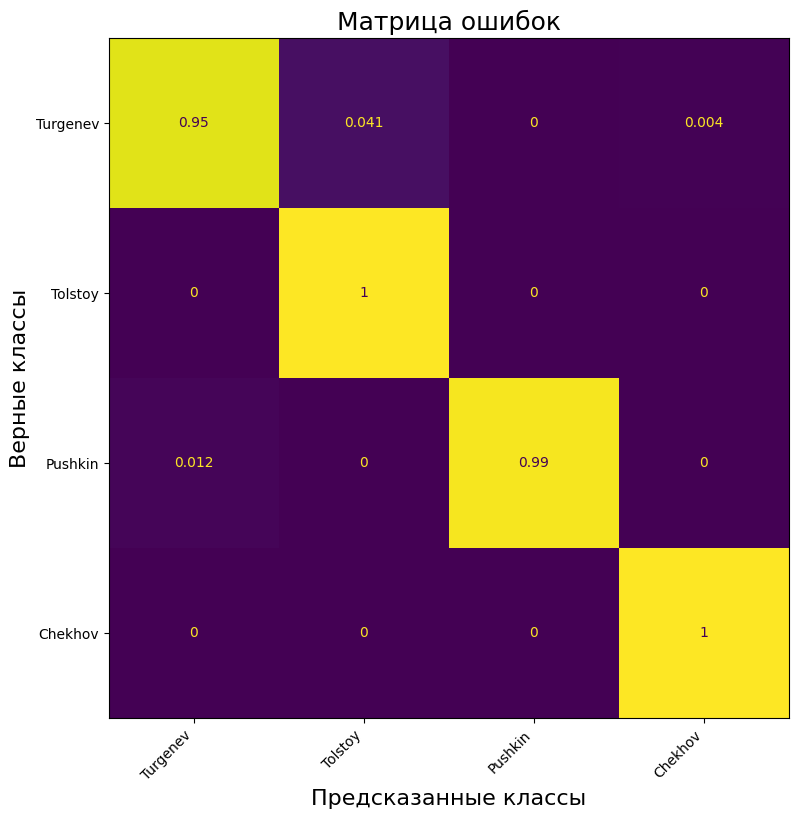


Средняя точность распознавания:  99%


In [71]:
y_pred_mix = model_MIX.predict(x_test)
show_confusion_matrix(y_test, y_pred_mix, CLASS_LIST_BALANCE)

In [75]:
#стих собственного сочинения
own_text = 'Волшебные миры над нами, пока веет запахом летним, На небосводе зависли огнями, и смотрю я на склон. Кругом парят облака, таинственно встали деревья, Дневная спала жара, все будто видеофон. Гуляет тихо туман, он окутал подножие склона, «Однажды ступал тут» - подумал вдруг я, Был без страха устремлен в далекие годы, Где менялась с погода дуновением Весна. Пространство предстало безмерным, раньше было одно, «Все знакомое было знакомым» - все думал я глядя на склон. Я, смотря на часы, видел время. Мне шепот странствий твердит, Что однажды туман тот рассею, легким движением руки. Меня тянет спуститься по склону, оглядеть, что было спрятано там, Но вдохнув свежестью летней, я взглянул вверх и кто-то сказал: «Однажды сомкнуться миры, все миры где будем когда-то, Тот туман, что у подножия - быль, от глаз что не была спрятана.»'

In [74]:
own_text

'Волшебные миры над нами, пока веет запахом летним, На небосводе зависли огнями, и смотрю я на склон. Кругом парят облака, таинственно встали деревья, Дневная спала жара, все будто видеофон. Гуляет тихо туман, он окутал подножие склона, «Однажды ступал тут» - подумал вдруг я, Был без страха устремлен в далекие годы, Где менялась с погода дуновением Весна. Пространство предстало безмерным, раньше было одно, «Все знакомое было знакомым» - все думал я глядя на склон. Я, смотря на часы, видел время. Мне шепот странствий твердит, Что однажды туман тот рассею, легким движением руки. Меня тянет спуститься по склону, оглядеть, что было спрятано там, Но вдохнув свежестью летней, я взглянул вверх и кто-то сказал: «Однажды сомкнуться миры, все миры где будем когда-то, Тот туман, что у подножия - быль, от глаз что не была спрятана.»'

In [76]:
import numpy as np
from keras.preprocessing.sequence import pad_sequences

# Функция для предобработки текста (замените на вашу функцию, если есть)
def preprocess_text(text):
    # Токенизация текста, например, с использованием ваших словарей
    tokens = tokenizer.texts_to_sequences([text])  # Замените tokenizer на ваш
    return pad_sequences(tokens, maxlen=WIN_SIZE)  # WIN_SIZE - ваша длина последовательности

# Подготовка текста
processed_text = preprocess_text(own_text)

# Получение предсказаний модели
predictions = model_MIX.predict(processed_text)

# Предположим, что CLASS_LIST_BALANCE - это список ваших классов
predicted_class_index = np.argmax(predictions, axis=1)[0]
predicted_class = CLASS_LIST_BALANCE[predicted_class_index]

print(f"Предполагаемый автор: {predicted_class}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
Предполагаемый автор: Tolstoy
